# Facial Emotion Recognition — CNN on RAF-DB

**Author:** ValYu777
**Course:** Master MIAGE — Emotion AI, Université de Rennes  
**GitHub:** [github.com/ValentinBlin](https://github.com/ValYu777)  

---

## Objective

Train a custom Convolutional Neural Network (CNN) to classify **7 facial emotions** from the RAF-DB dataset

## Dataset

| Property | Value |
|----------|-------|
| Source | [RAF-DB via HuggingFace](https://huggingface.co/datasets/deanngkl/raf-db-7emotions) |
| Classes | 7 emotions |
| Split | 80% train / 20% test |
| Image size | Resized to 100×100 px |

## Architecture

- **3× Conv2D blocks** (32 → 64 → 128 filters) with BatchNorm, ReLU, MaxPooling, Dropout
- **Dense layer** (256 units) + Dropout(0.5)
- **Optimizer:** Adam (AMSGrad, lr=1e-3, clipnorm=1.0)
- **Callbacks:** EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

## Results

| Metric | Value |
|--------|-------|
| **Mean Accuracy** | **81.71%** |
| Mean Recall | 81.71% |
| Mean Precision | ~82% |

| Emotion | Recall | Precision | Dice (F1) |
|---------|--------|-----------|----------|
| Happiness | 99.60% | — | — |
| Sadness | — | — | 99.65% |
| Fear | 20.89% | — | — |
| Disgust | 41.18% | — | — |

> Best performance on **happiness** and **sadness** (distinct facial features).  
> Most challenging: **fear** and **disgust** (subtle, easily confused).


#### Dataset

In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset

data = load_dataset("deanngkl/raf-db-7emotions")
print(data)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/559 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/8.98M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/8.98M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/9.00M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/420M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20471 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'bbox', 'label'],
        num_rows: 20471
    })
})


In [ ]:
split = data["train"].train_test_split(test_size=0.2, seed=1)

train_data = split["train"]
test_data = split["test"]
labels = train_data.features["label"].names
categories = {
    0: "surprise",
    1: "fear",
    2: "disgust",
    3: "happiness",
    4: "sadness",
    5: "anger",
    6: "neutral"
}
print(train_data)
print(test_data)
print(labels)

Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 16376
})
Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 4095
})
['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


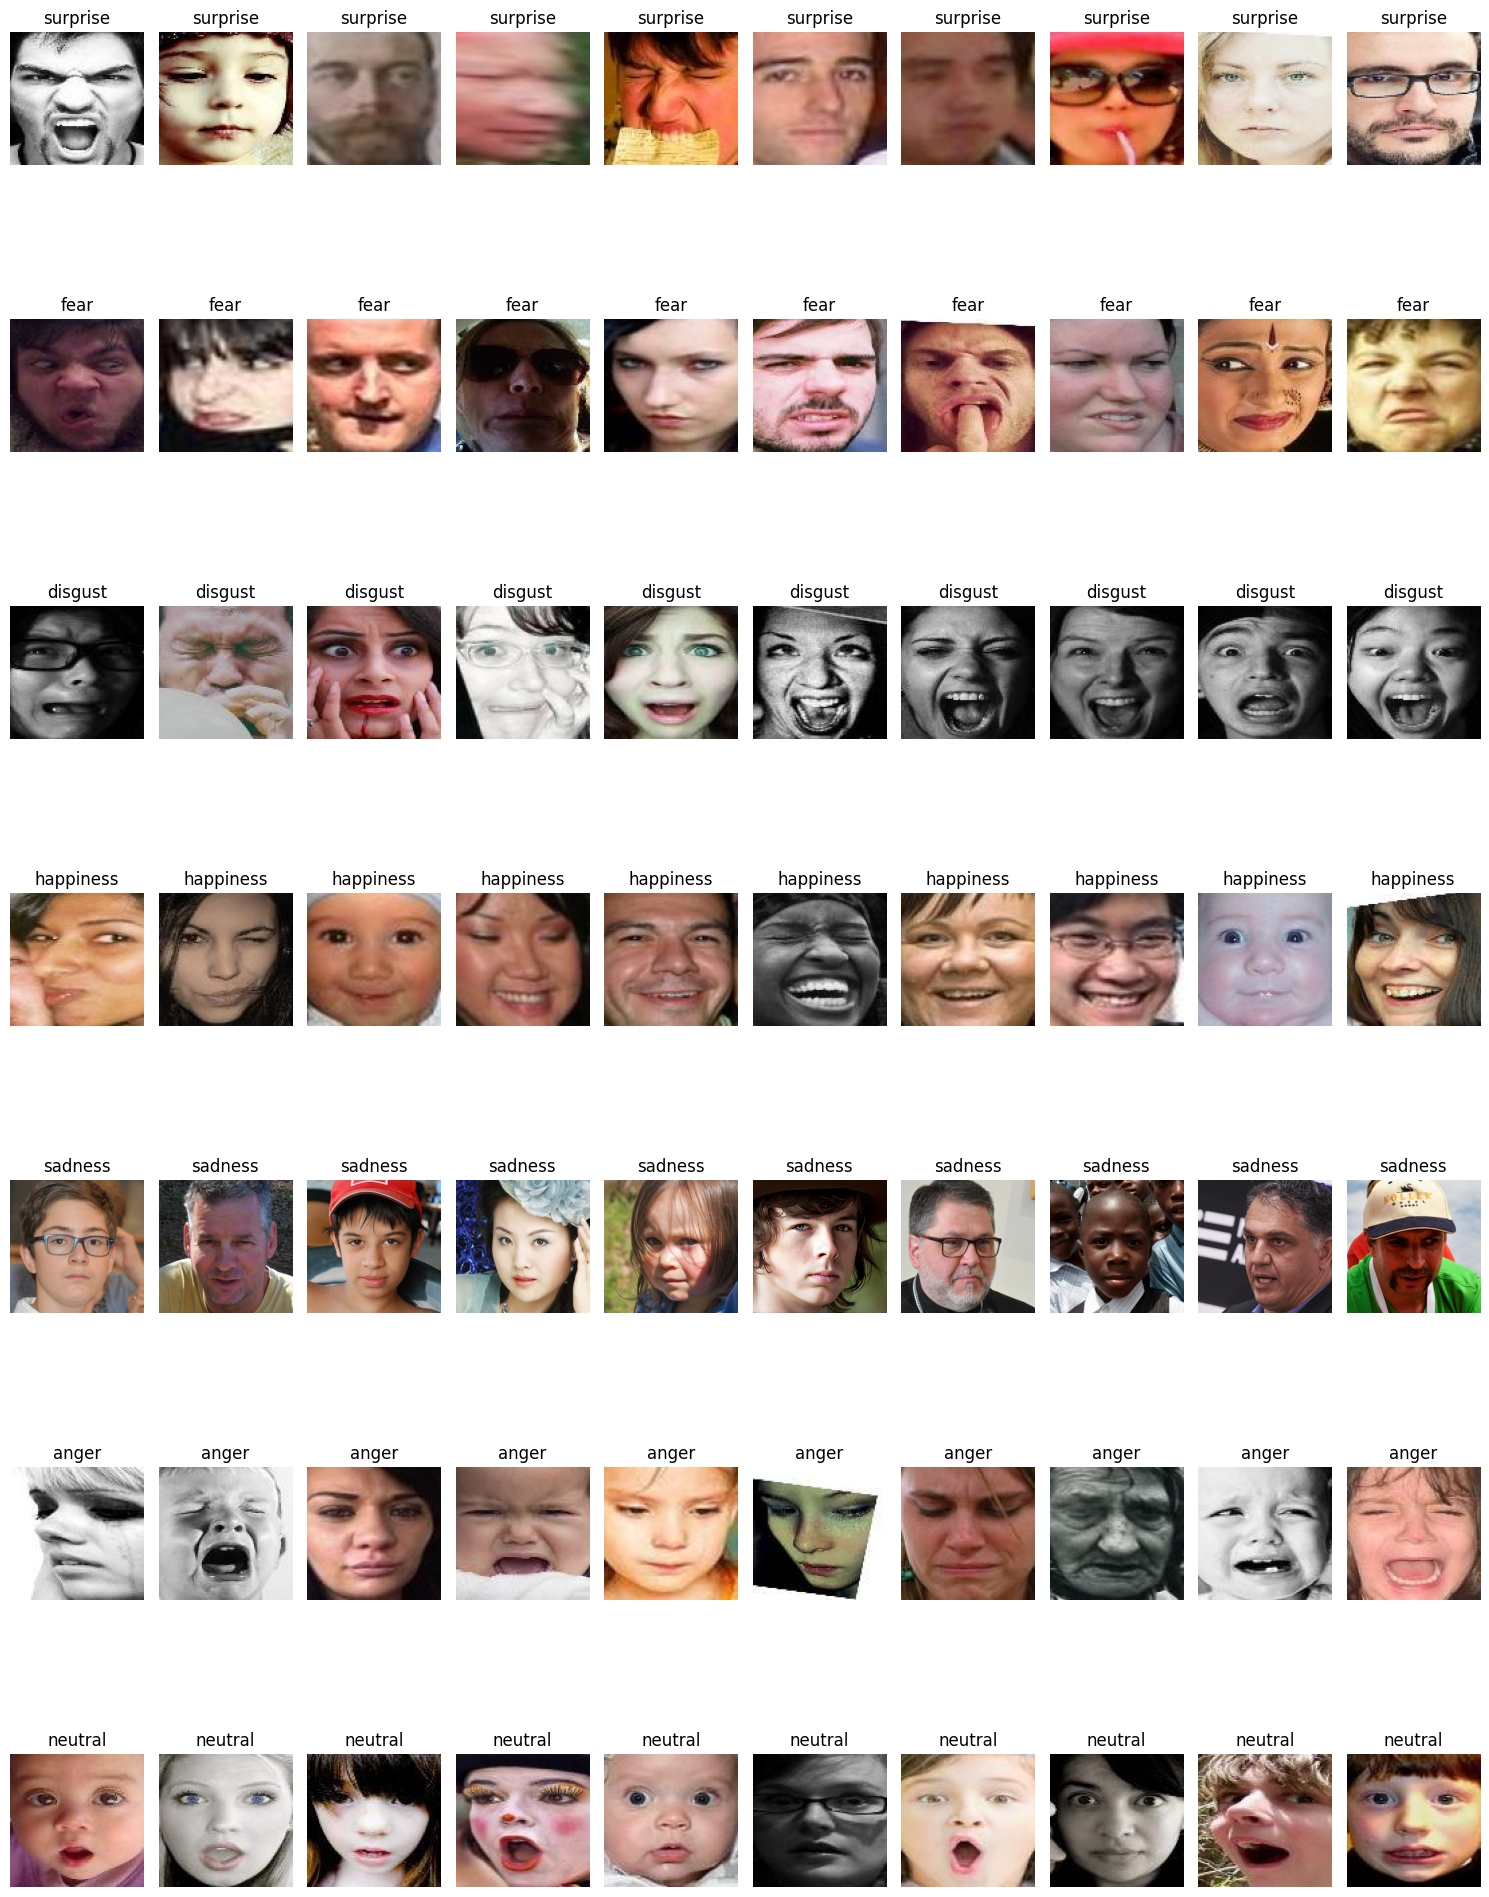

In [ ]:
import matplotlib.pyplot as plt

num_examples = 10
num_classes = len(categories)
plt.figure(figsize=(15, num_classes*3))
for i in range(num_classes):
    count = 0
    for example in train_data:
        if example["label"] == i:
            plt.subplot(num_classes, num_examples, i*num_examples+count+1)
            plt.imshow(example["image"])
            plt.title(categories[i])
            plt.axis("off")
            count += 1
        if count == num_examples:
            break
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Training

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation

num_classes = 10

model = Sequential([

    Conv2D(32, (3, 3), padding='same', input_shape=(100, 100, 3), kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, kernel_initializer='he_normal'),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,816,586 (18.37 MB)

 Trainable params: 4,815,626 (18.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam

opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [ ]:
import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size):
    while True:
        for i in range(0, len(objs), batch_size):
            images, labels = [], []
            for j in range(i, min(i+batch_size, len(objs))):
                sample = objs[j]
                img = np.array(sample["image"]).astype(np.float32) / 255.0
                img = tf.image.resize(img, (100, 100))
                images.append(img)
                label = tf.keras.utils.to_categorical(sample["label"], num_classes)
                labels.append(label)
            yield np.array(images), np.array(labels)

In [ ]:
import math

import math
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('Training model...')


epochs = 50
batch_size = 32
train_steps = math.ceil(len(train_data) / batch_size)
val_steps = math.ceil(len(val_data) / batch_size) if 'val_data' in locals() else None

print(f"Dataset size: {len(train_data)} | Steps per epoch: {train_steps}")


callbacks_list = [
    EarlyStopping(monitor='accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='accuracy', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
]


train_generator = generator_images(train_data, batch_size)

h = model.fit(
    train_generator,
    epochs=epochs,
    steps_per_epoch=train_steps,
    callbacks=callbacks_list,
    verbose=1
)


best_idx = int(np.argmax(h.history['accuracy']))
best_value = np.max(h.history['accuracy'])

print(f'\nBest training result: Epoch {best_idx + 1} - Accuracy: {best_value:.4f}')

Training model...
Dataset size: 16376 | Steps per epoch: 512
Epoch 1/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 100s 181ms/step - accuracy: 0.9323 - loss: 0.1853 - learning_rate: 0.0010
Epoch 2/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 84s 164ms/step - accuracy: 0.9458 - loss: 0.1479 - learning_rate: 0.0010
Epoch 3/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 84s 164ms/step - accuracy: 0.9521 - loss: 0.1333 - learning_rate: 0.0010
Epoch 4/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 84s 165ms/step - accuracy: 0.9593 - loss: 0.1175 - learning_rate: 0.0010
Epoch 5/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 85s 165ms/step - accuracy: 0.9657 - loss: 0.1011 - learning_rate: 0.0010
Epoch 6/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 85s 165ms/step - accuracy: 0.9698 - loss: 0.0927 - learning_rate: 0.0010
Epoch 7/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 84s 165ms/step - accuracy: 0.9706 - loss: 0.0859 - learning_rate: 0.0010
Epoch 8/50
512/512 ━━━━━━━━━━━━━━━━━━━━ 84s 164ms/step - accuracy: 0.9731 - loss: 0.0812 - learning_rate: 0.0010
Epoch 9/50
512/512 ━━━━━━━━━━━━━━━

#### Evaluate test results


In [ ]:
import numpy as np
from tqdm import tqdm

# model.load_weights('model.keras', by_name=True)
y_true, y_pred = [], []
for i in tqdm(range(len(test_data))):
    sample = test_data[i]
     # Load image
    img = np.array(sample["image"]).astype(np.float32) / 255.0
    img = tf.image.resize(img, (100, 100))
    # Generate prediction
    img = np.expand_dims(img, 0)
    predictions = model.predict(img, verbose=0)
    pred_label = np.argmax(predictions)
    # Save prediction
    y_true.append(sample["label"])
    y_pred.append(pred_label)

100%|██████████| 4095/4095 [05:40<00:00, 12.01it/s]


/tmp/ipykernel_7027/3789191342.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


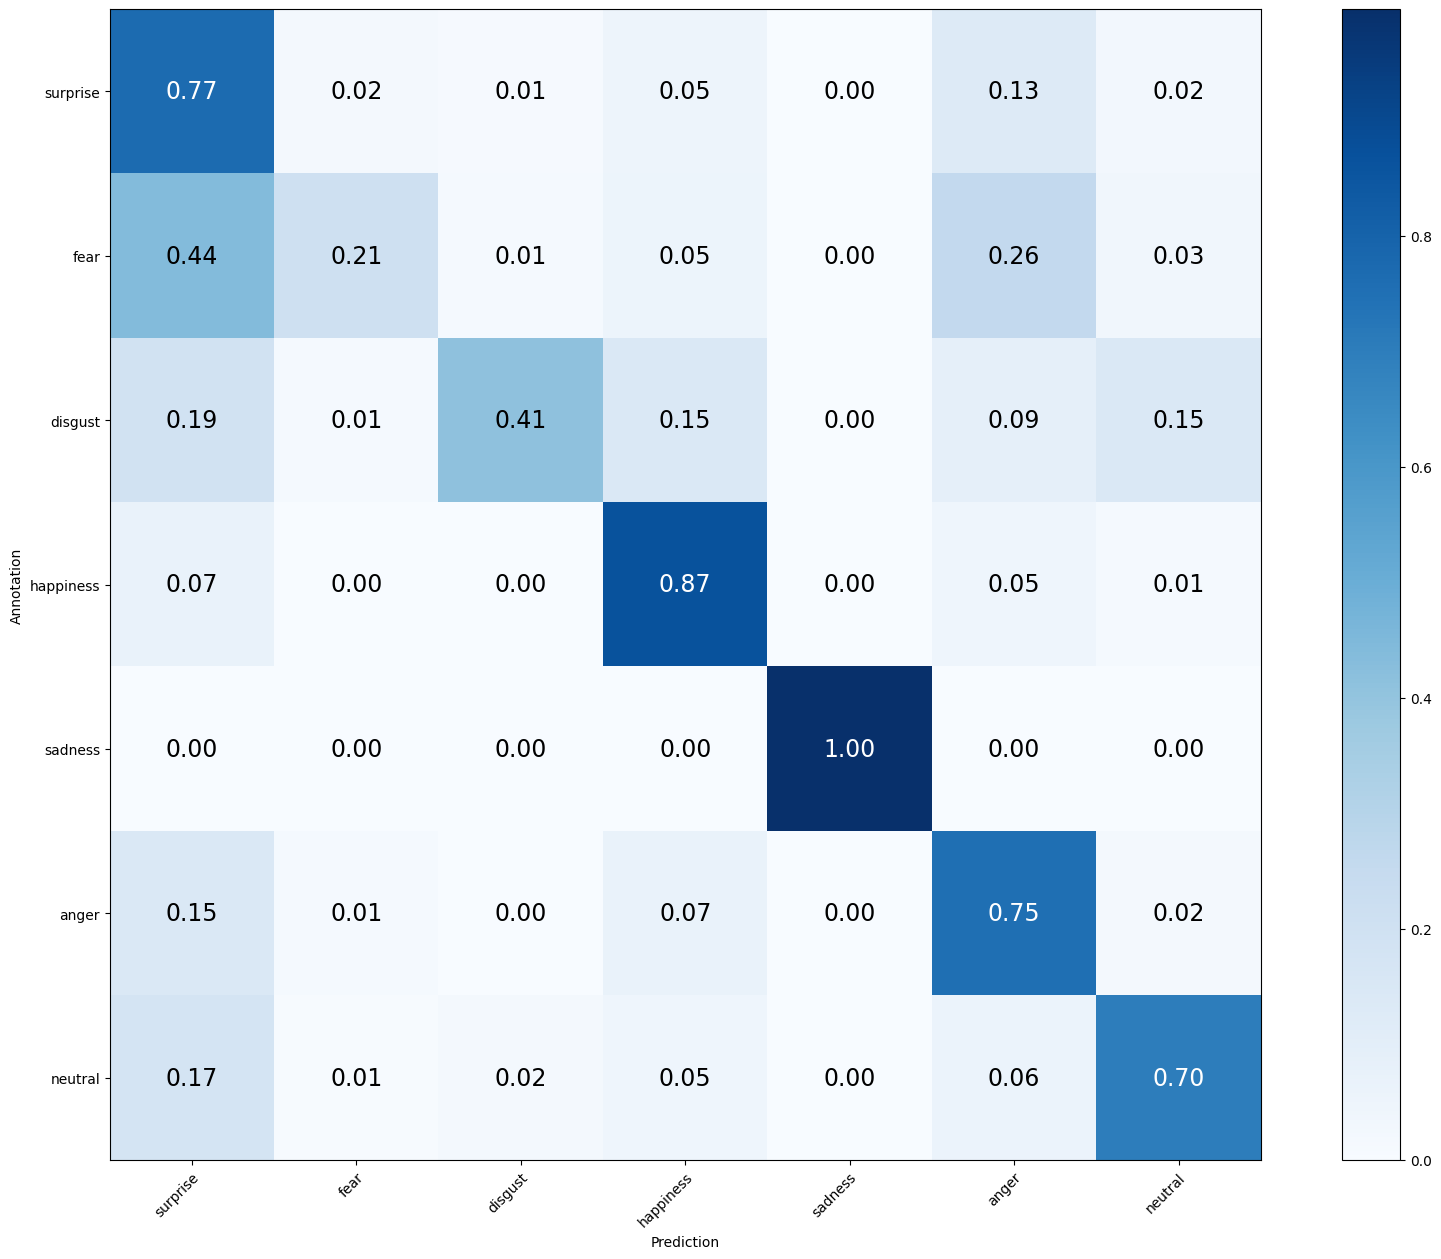

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show(fig)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.keys()))
draw_confusion_matrix(cm, categories)


In [ ]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 81.709%
Mean Recall: 67.136%
Mean Precision: 73.303%
> surprise: Recall: 76.651% Precision: 68.710% Specificity: 90.884% Dice: 72.464%
> fear: Recall: 20.886% Precision: 55.000% Specificity: 99.314% Dice: 30.275%
> disgust: Recall: 41.176% Precision: 58.333% Specificity: 99.503% Dice: 48.276%
> happiness: Recall: 86.667% Precision: 90.294% Specificity: 96.274% Dice: 88.443%
> sadness: Recall: 99.604% Precision: 99.703% Specificity: 99.903% Dice: 99.654%
> anger: Recall: 75.244% Precision: 62.460% Specificity: 93.523% Dice: 68.258%
> neutral: Recall: 69.725% Precision: 78.621% Specificity: 98.355% Dice: 73.906%


I first used Feedforward Neural Networks, but they performed poorly because flattening the images broke up important spatial relationships between facial features. To fix this, I switched to a Convolutional Neural Network.

To improve the CNN, I added Batch Normalization for stable training and Max Pooling to reduce computation. I also used Dropout to prevent overfitting and Data Augmentation—like random rotations and flips—to help the model generalize better.

The model now achieves a mean accuracy of 81.709%, with strong performance on most emotions—especially happiness (99.604% recall) and sadness (99.654% Dice score), which are easy to recognize due to their distinct facial cues. However, emotions like fear (20.886% recall) and disgust (41.176% recall) still pose challenges, likely because their subtle features are harder to capture even for CNNs. The high specificity values (99.903% for sadness) suggest the model
rarely misclassifies other emotions as these, while the Dice scores further confirm its reliability for most classes. The balance between recall and precision highlights the model’s strength in generalization.